## Global Setup & Data Management
* Import libraries
* Create data folder
* Set active channels
* Set trigger voltage

In [ ]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from datetime import datetime
from IPython.display import clear_output
from scipy.stats import poisson

In [ ]:
# General Parameters
ACTIVE_CHANNELS = list(range(1, 16))  # List all available channels. 
TRIGGER_VOLTAGE = 0.5   # volts

# Data Folder 
SAVE_DIR = "../data/raw/correlation_15ch/data_cw_correlations_run3" # Edit name
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Session initialized. All data will be saved to: {SAVE_DIR}")

# Initialize tagger object instance
tagger = tt.createTimeTagger()
print(f"Connected to Time Tagger: {tagger.getSerial()}")
for ch in ACTIVE_CHANNELS:
    tagger.setTriggerLevel(ch, TRIGGER_VOLTAGE)

## Deadtime & 1% Rule Target
* Deadtime calculation. 
* Maximum theoretical rate for SPAD $1/t_d$
* Operating cps must be $1/100 t_d$

Measuring deadtimes across all channels in parallel...
Channel 1 Deadtime: 5.90 ns
Channel 2 Deadtime: 5.90 ns
Channel 3 Deadtime: 5.80 ns
Channel 4 Deadtime: 6.00 ns
Channel 5 Deadtime: 6.40 ns
Channel 6 Deadtime: 6.70 ns
Channel 7 Deadtime: 5.70 ns
Channel 8 Deadtime: 6.70 ns
Channel 9 Deadtime: 6.70 ns
Channel 10 Deadtime: 6.60 ns
Channel 11 Deadtime: 7.20 ns
Channel 12 Deadtime: 6.00 ns
Channel 13 Deadtime: 6.30 ns
Channel 14 Deadtime: 6.60 ns
Channel 15 Deadtime: 6.00 ns


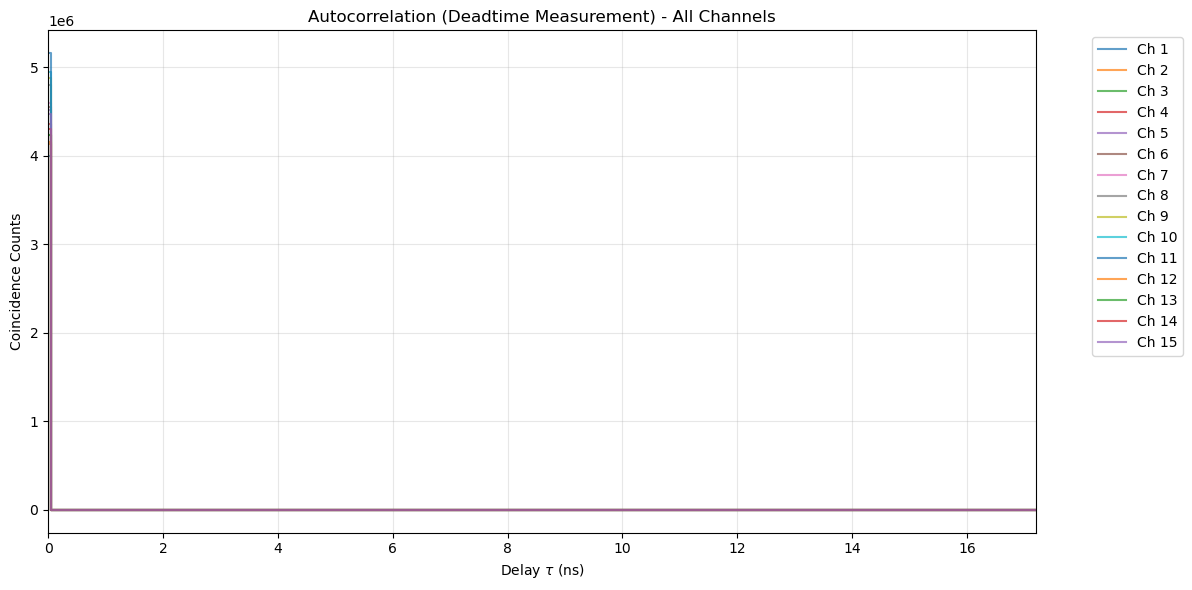

----------------------------------------
Maximum Array Deadtime: 7.20 ns
Theoretical Max Rate: 138,888,889 cps
TARGET OPERATION RATE (1% Rule): 1,388,889 cps


In [ ]:
# Assuming SAVE_DIR and tagger are already previusly defined
BIN_WIDTH_PS = 100
N_BINS = 500000  # Wide enough to capture a ~50ns deadtime
MEASURE_TIME_PS = int(5e12) # 5 seconds

print("Measuring deadtimes across all channels in parallel...")
autocorrelations = {}

# Initialize all measurement classes
for ch in ACTIVE_CHANNELS:
    autocorrelations[ch] = tt.Correlation(tagger, channel_1=ch, channel_2=ch, binwidth=BIN_WIDTH_PS, n_bins=N_BINS)

# Start simultaneous acquisitions
for ch in ACTIVE_CHANNELS:
    autocorrelations[ch].startFor(MEASURE_TIME_PS, clear=True)

# Halt Python until ALL hardware measurements are finished
for ch in ACTIVE_CHANNELS:
    autocorrelations[ch].waitUntilFinished()

#Extract, Plot, and Save Data
deadtimes_ps = {}

# Set up the combined plot
plt.figure(figsize=(12, 6))

for ch in ACTIVE_CHANNELS:
    lags = autocorrelations[ch].getIndex()
    counts = autocorrelations[ch].getData()
    
    # Save the raw array for each pixel
    np.save(os.path.join(SAVE_DIR, f"autocorr_raw_ch{ch}.npy"), counts)
    
    # Mask out tau <= 1000 ps to ignore the tau=0 self-coincidence peak / jitter
    valid_mask = lags > 1000 
    valid_lags = lags[valid_mask]
    valid_counts = counts[valid_mask]
    
    # Find where counts exceed 1 count (Per your specification)
    recovery_idx = np.argmax(valid_counts > 1)
    
    deadtimes_ps[ch] = valid_lags[recovery_idx]
    print(f"Channel {ch} Deadtime: {deadtimes_ps[ch] / 1000:.2f} ns")
    
    # Add to the combined plot
    plt.plot(lags / 1000, counts, drawstyle='steps-mid', alpha=0.7, label=f'Ch {ch}')

# Save the time axis (lags) just once since it is identical for all channels
np.save(os.path.join(SAVE_DIR, "autocorr_lags.npy"), lags)

# Format the combined plot
plt.title("Autocorrelation (Deadtime Measurement) - All Channels")
plt.xlabel("Delay $\\tau$ (ns)")
plt.ylabel("Coincidence Counts")
plt.xlim(0, max(deadtimes_ps.values()) / 1000 + 10)  #Zoom on x axis. 
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the plot image and display it
plt.savefig(os.path.join(SAVE_DIR, "autocorr_all_pixels.png"), dpi=300)
plt.show()

# 5. Calculate 1% Rule Target
max_dt_ps = max(deadtimes_ps.values())
max_dt_sec = max_dt_ps * 1e-12
theoretical_max_cps = 1 / max_dt_sec
TARGET_CPS = theoretical_max_cps * 0.01

print("-" * 40)
print(f"Maximum Array Deadtime: {max_dt_ps / 1000:.2f} ns")
print(f"Theoretical Max Rate: {theoretical_max_cps:,.0f} cps")
print(f"TARGET OPERATION RATE (1% Rule): {TARGET_CPS:,.0f} cps")

## Live Count Rate Monitor (ND Filter Tuning)
* run 1 : 62.8mA, 1.685V == 37.5 mu W
* 2 : 56.9 mA 1.674  == 4.046 mu W

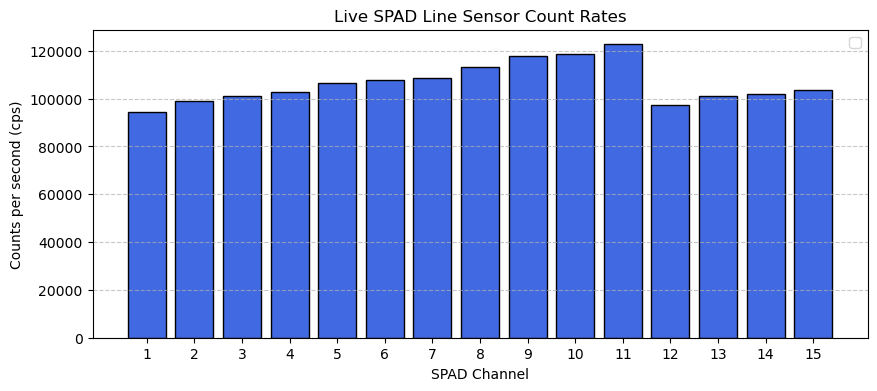

ND Filter tuning complete. Proceed to photon statistics.


In [ ]:
print("Starting live monitor. Adjust ND filters to align with the red target line.")
print("Interrupt the kernel (Stop button) to exit the live loop.")
time.sleep(2)

rate_monitor = tt.Countrate(tagger, channels=ACTIVE_CHANNELS)

try:
    while True:
        rate_monitor.startFor(int(1e11), clear=True) # 0.1 second updates
        rate_monitor.waitUntilFinished()
        rates = rate_monitor.getData()
        
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.bar(ACTIVE_CHANNELS, rates, color='royalblue', edgecolor='black')
        #plt.axhline(TARGET_CPS, color='red', linestyle='--', linewidth=2, label=f'1% Target ({TARGET_CPS:,.0f} cps)')
        
        plt.title("Live SPAD Line Sensor Count Rates")
        plt.xlabel("SPAD Channel")
        plt.ylabel("Counts per second (cps)")
        
        # Set Y-axis to keep the target line in view
        plt.ylim(0, max(max(rates) * 1.2, TARGET_CPS * 2))
        plt.xticks(ACTIVE_CHANNELS)
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        
except KeyboardInterrupt:
    print("ND Filter tuning complete. Proceed to photon statistics.")

## Counts per time Window (Photon Statistics)
* For the Pseudo-Thermal Source: This is a massive trap. To observe a super-Poissonian (Bose-Einstein) distribution, the digital counting window (BIN_WIDTH_PS) must be much shorter than the coherence time ($\tau_c$) of the speckles.

Counting photons across 100,000 windows on Channel 1...
Data saved to data_cw_correlations_run2\photon_counts_ch1.npy


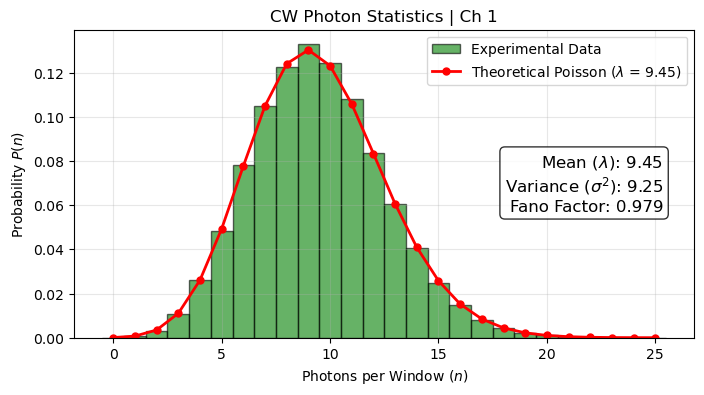

In [ ]:
TARGET_CH = 1                 # Channel to analyze
BIN_WIDTH_PS = int(1e8)       # 100 microseconds per window
N_WINDOWS = 100000            # 10 seconds total

# Measurement
print(f"Counting photons across {N_WINDOWS:,} windows on Channel {TARGET_CH}...")
counter = tt.Counter(tagger, channels=[TARGET_CH], binwidth=BIN_WIDTH_PS, n_values=N_WINDOWS)
counter.startFor(BIN_WIDTH_PS * N_WINDOWS, clear=True)
counter.waitUntilFinished()
counts_per_window = counter.getData()[0]

# Save Data
save_path = os.path.join(SAVE_DIR, f"photon_counts_ch{TARGET_CH}.npy")
np.save(save_path, counts_per_window)
print(f"Data saved to {save_path}")

# Analysis 
lambda_param = np.mean(counts_per_window)
variance = np.var(counts_per_window)
fano_factor = variance / lambda_param

min_c, max_c = np.min(counts_per_window), np.max(counts_per_window)
bins = np.arange(min_c, max_c + 2) - 0.5 

# Plot
plt.figure(figsize=(8, 4))
plt.hist(counts_per_window, bins=bins, density=True, color='green', edgecolor='black', alpha=0.6, label='Experimental Data')

x_theory = np.arange(min_c, max_c + 1)
y_theory = poisson.pmf(x_theory, lambda_param)
plt.plot(x_theory, y_theory, 'r-', marker='o', linewidth=2, markersize=5, label=f'Theoretical Poisson ($\\lambda$ = {lambda_param:.2f})')

plt.title(f'CW Photon Statistics | Ch {TARGET_CH}')
plt.xlabel('Photons per Window ($n$)')
plt.ylabel('Probability $P(n)$')

stats_text = f"Mean ($\\lambda$): {lambda_param:.2f}\nVariance ($\\sigma^2$): {variance:.2f}\nFano Factor: {fano_factor:.3f}"
plt.gca().text(0.95, 0.5, stats_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

## Cross Correlation function $g^{(2)}(\tau)$
* Diffuse Correlation Spectroscopy (DCS) decay curve, your correlation window needs to span the millisecond regime.


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 3 ---


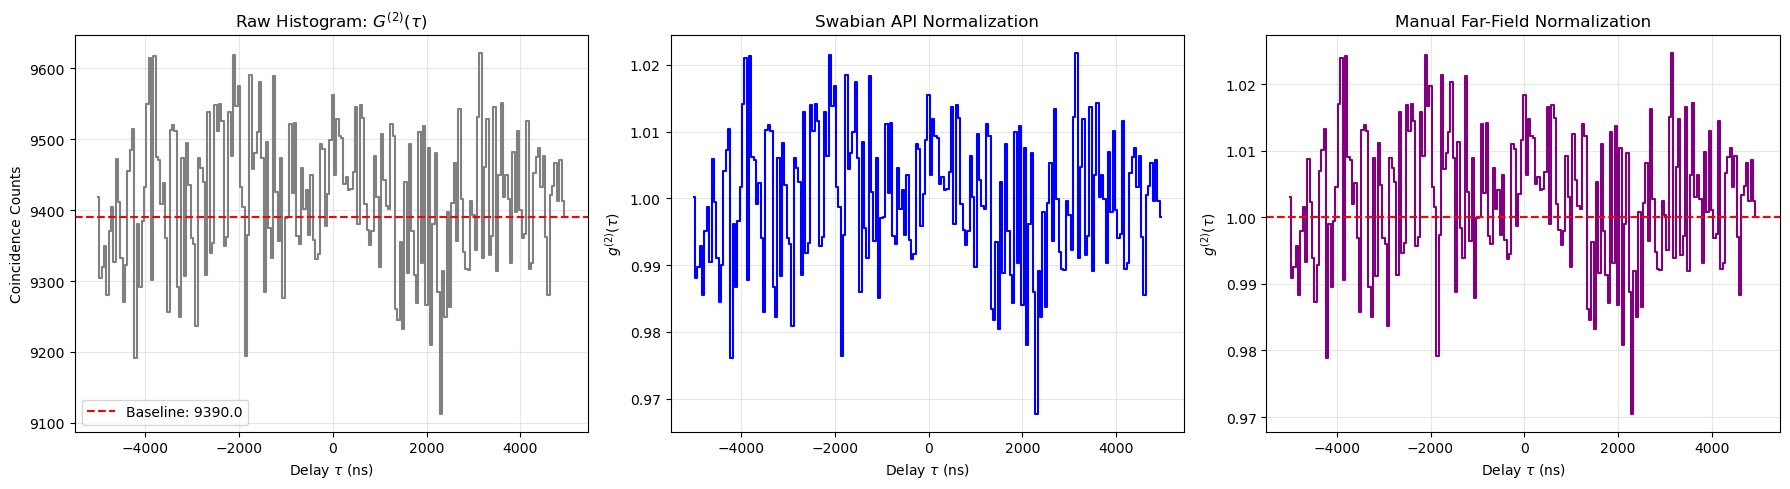


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 4 ---


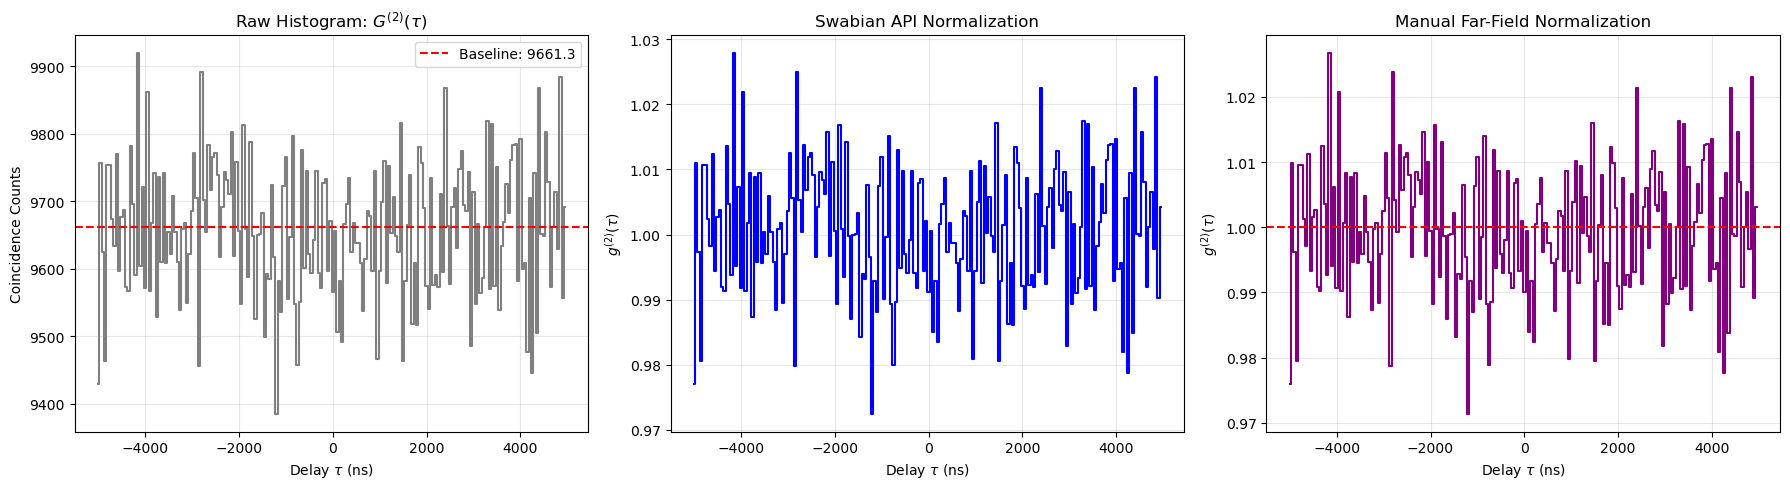


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 5 ---


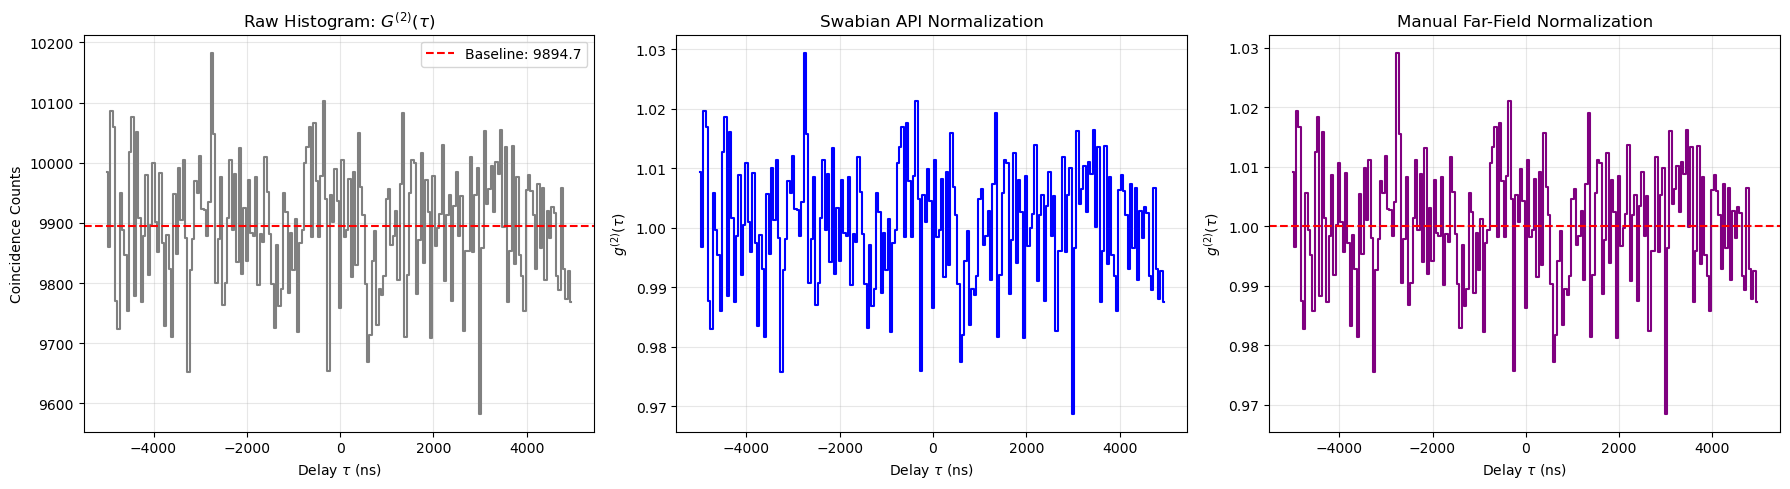


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 6 ---


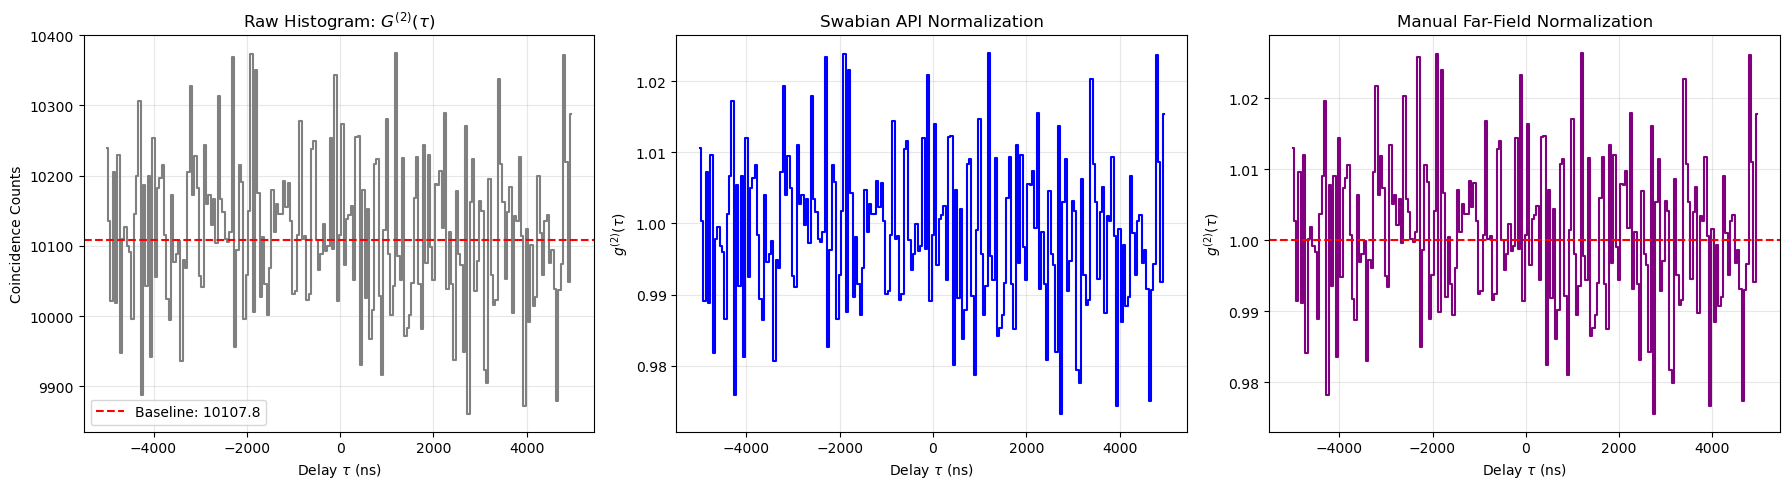


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 7 ---


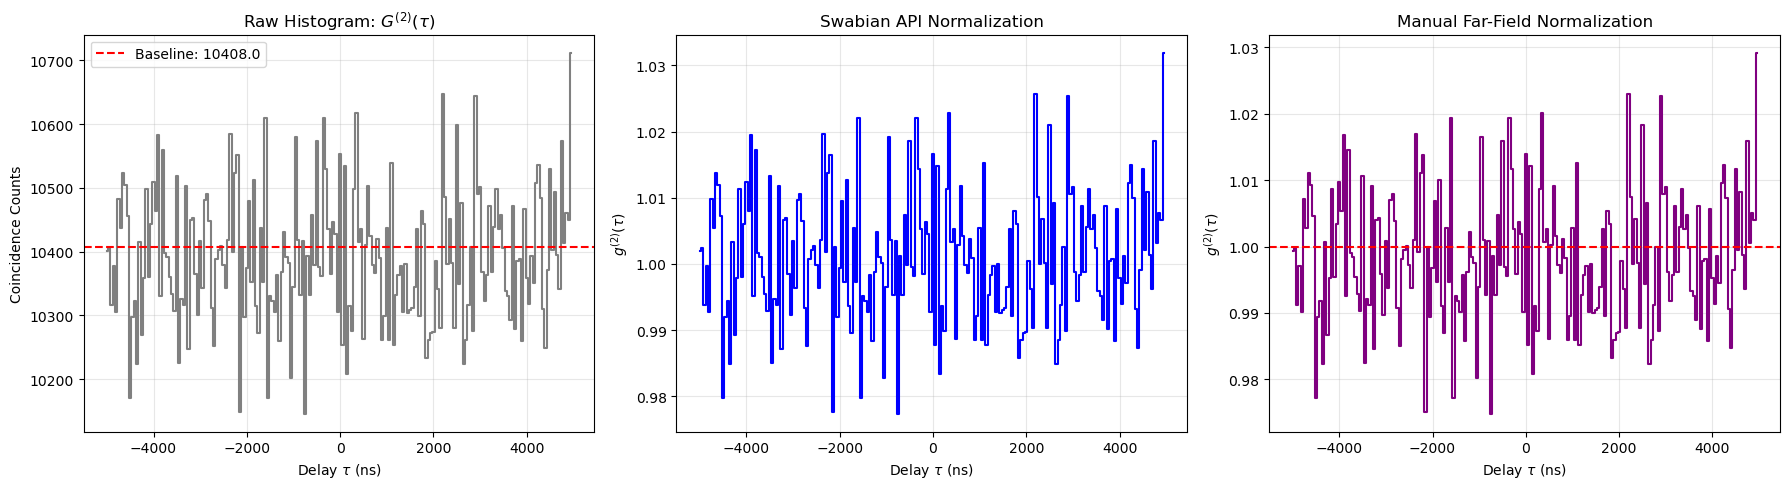


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 8 ---


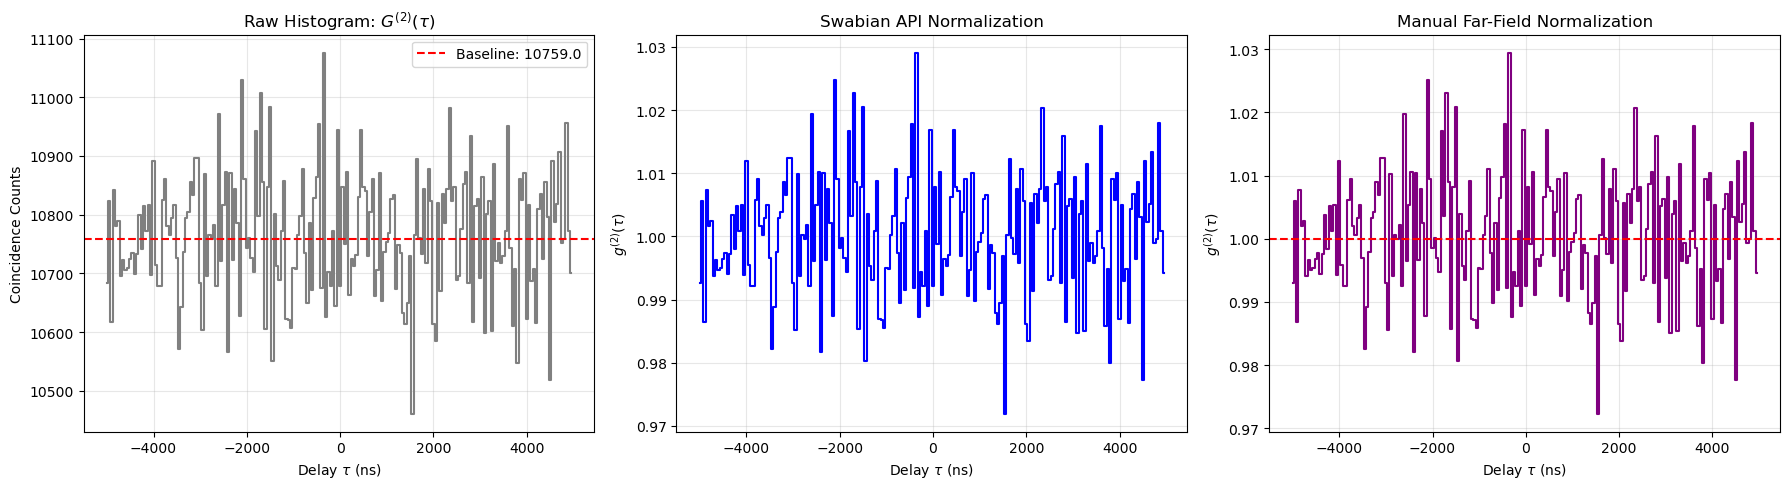


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 9 ---


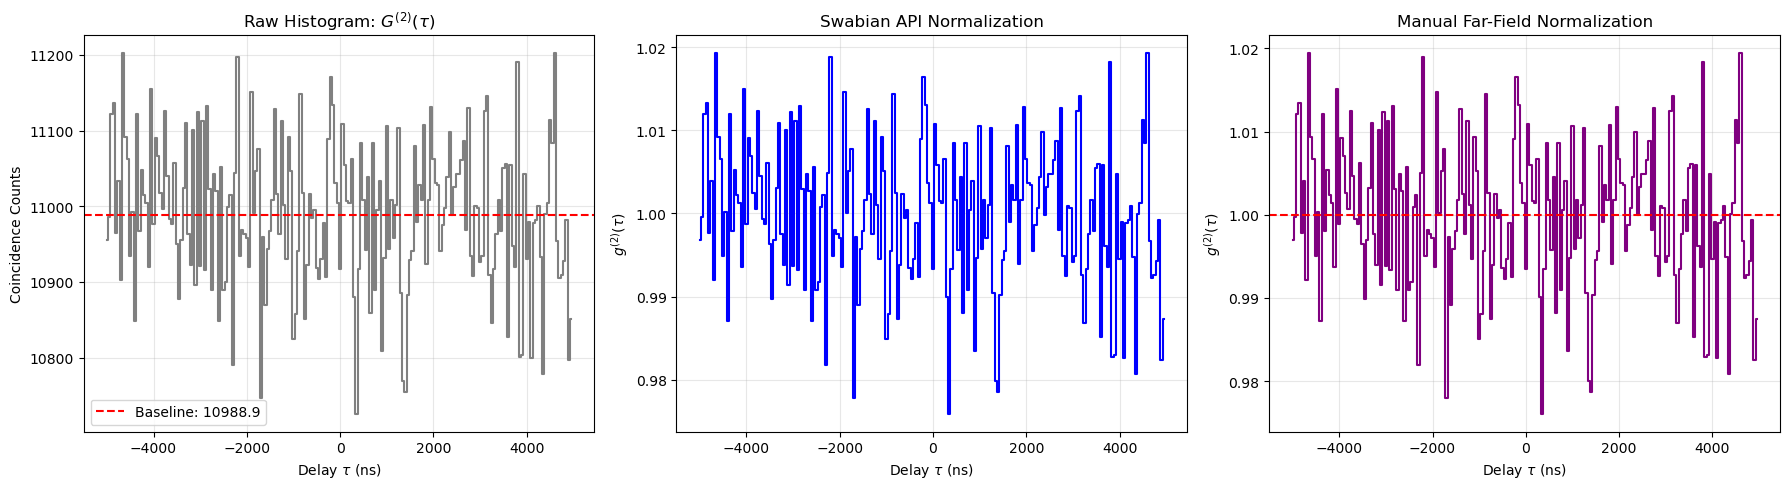


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 10 ---


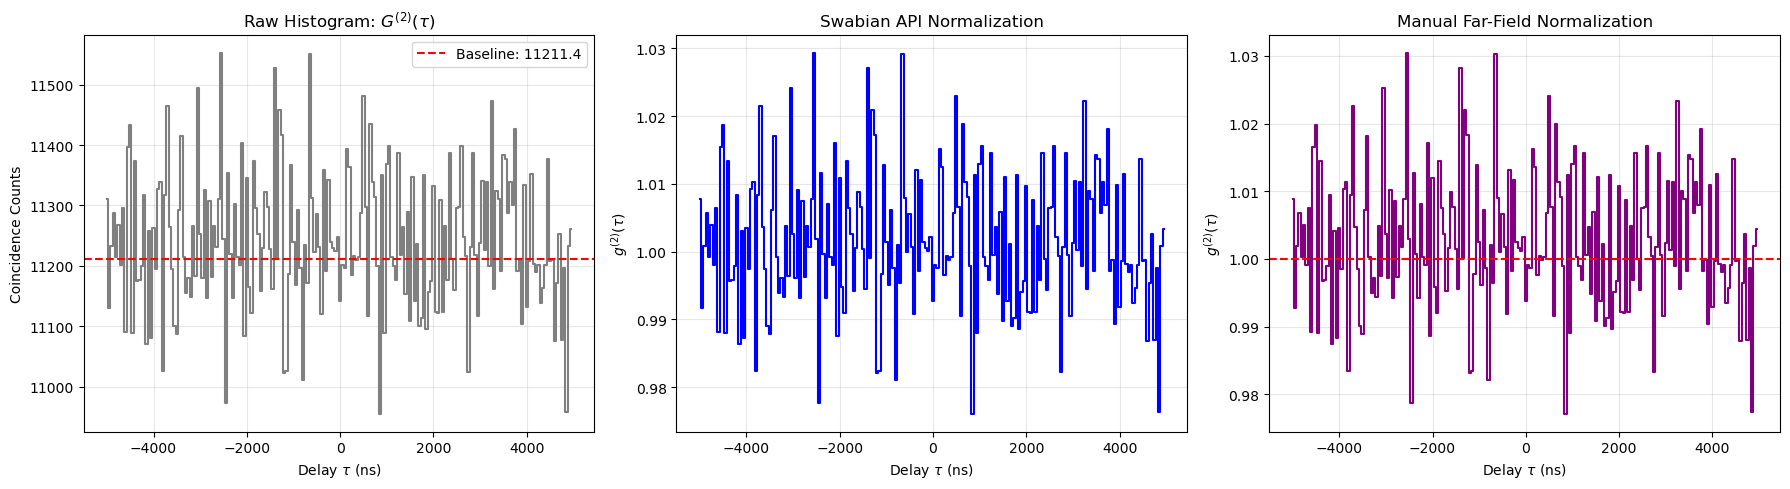


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 12 ---


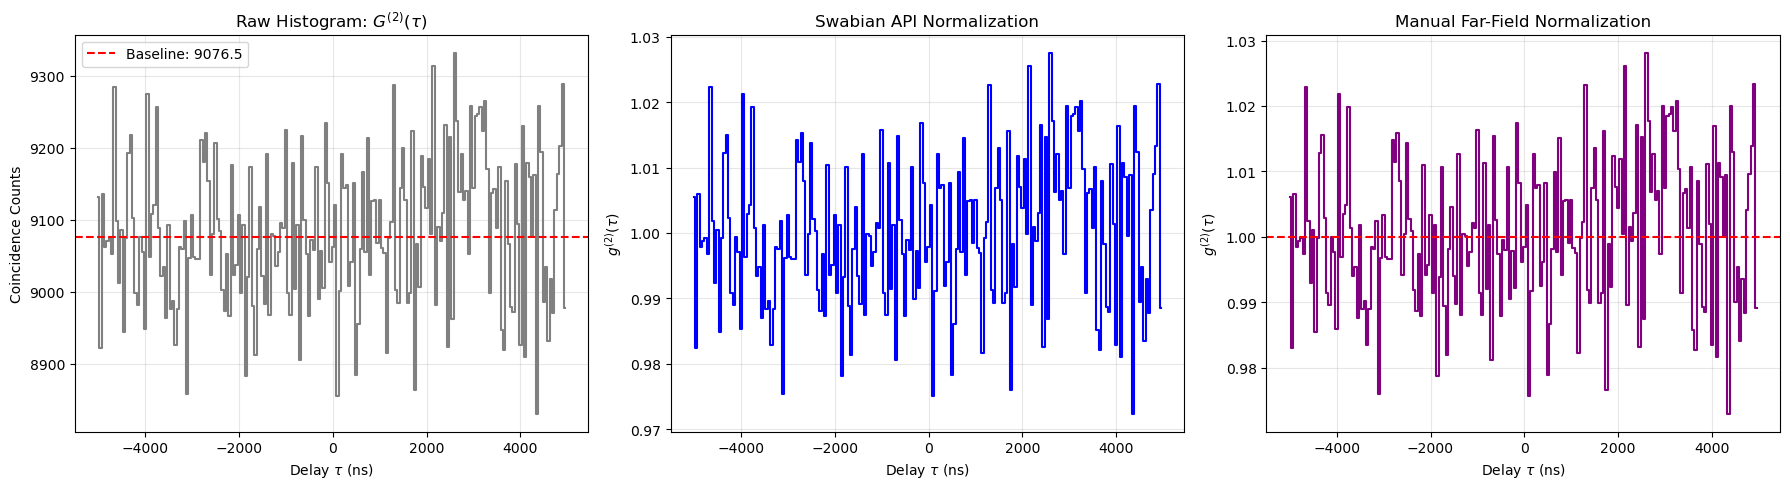


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 13 ---


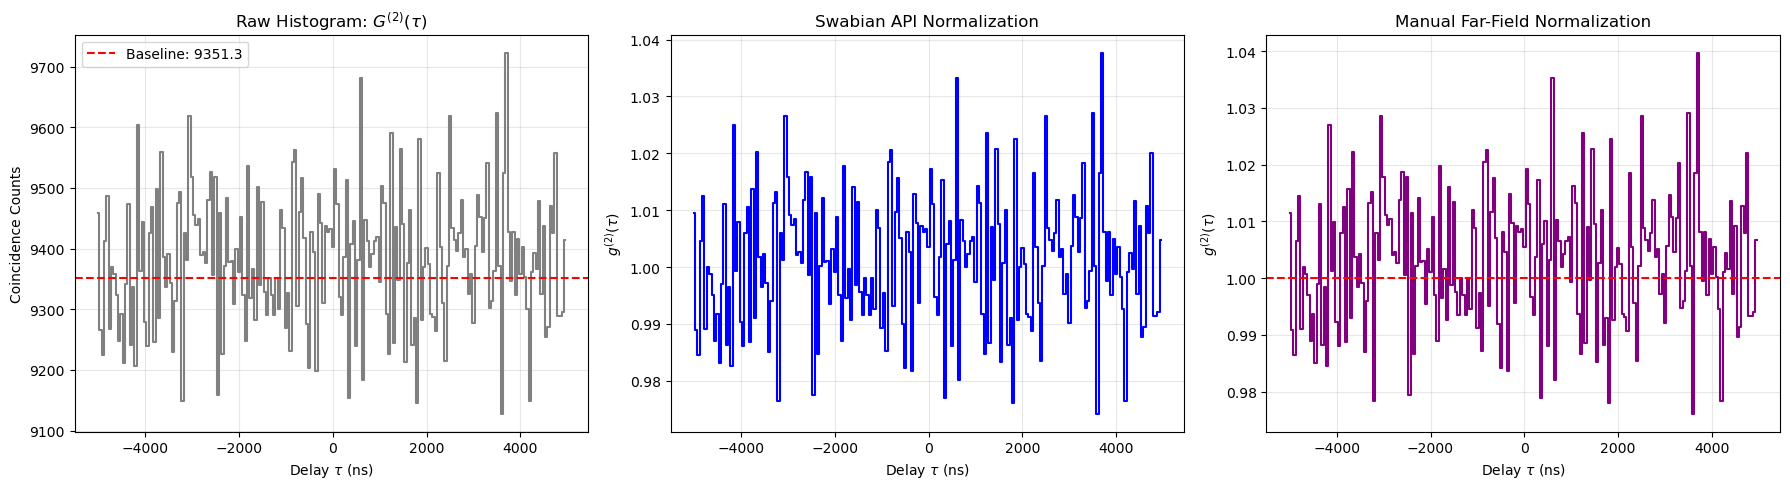


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 14 ---


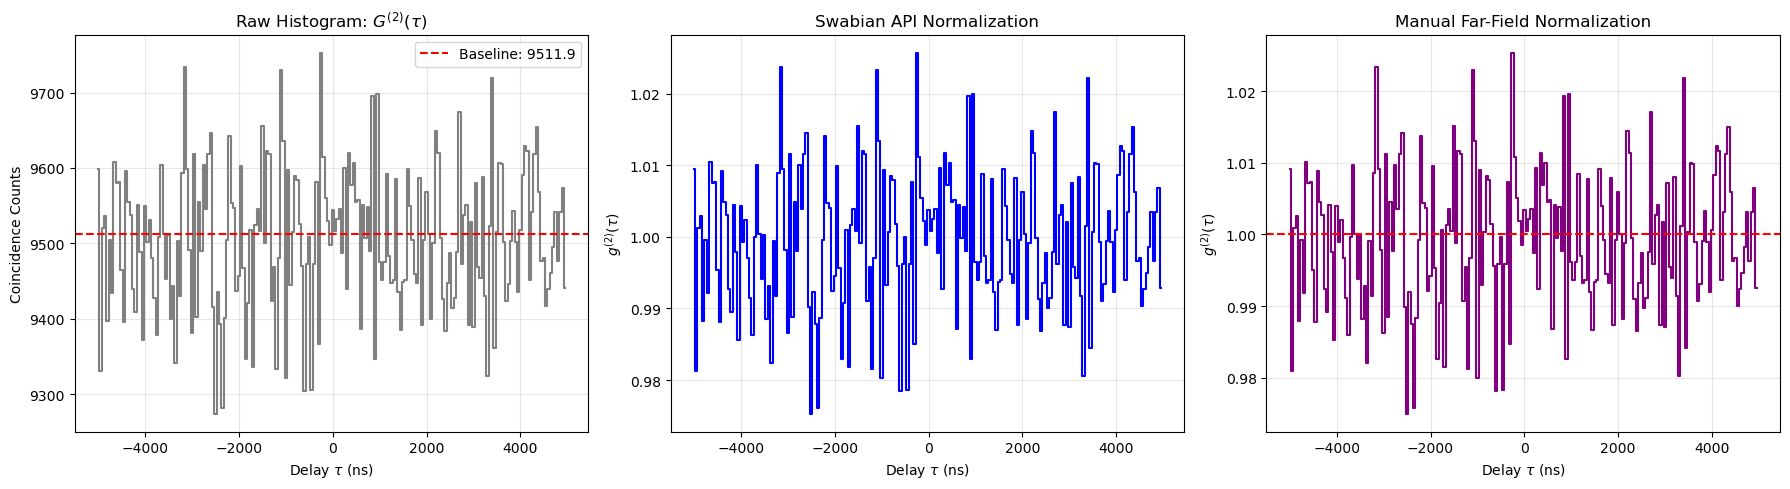


--- Measuring g2(tau) for Pair: Ch 1 vs Ch 15 ---


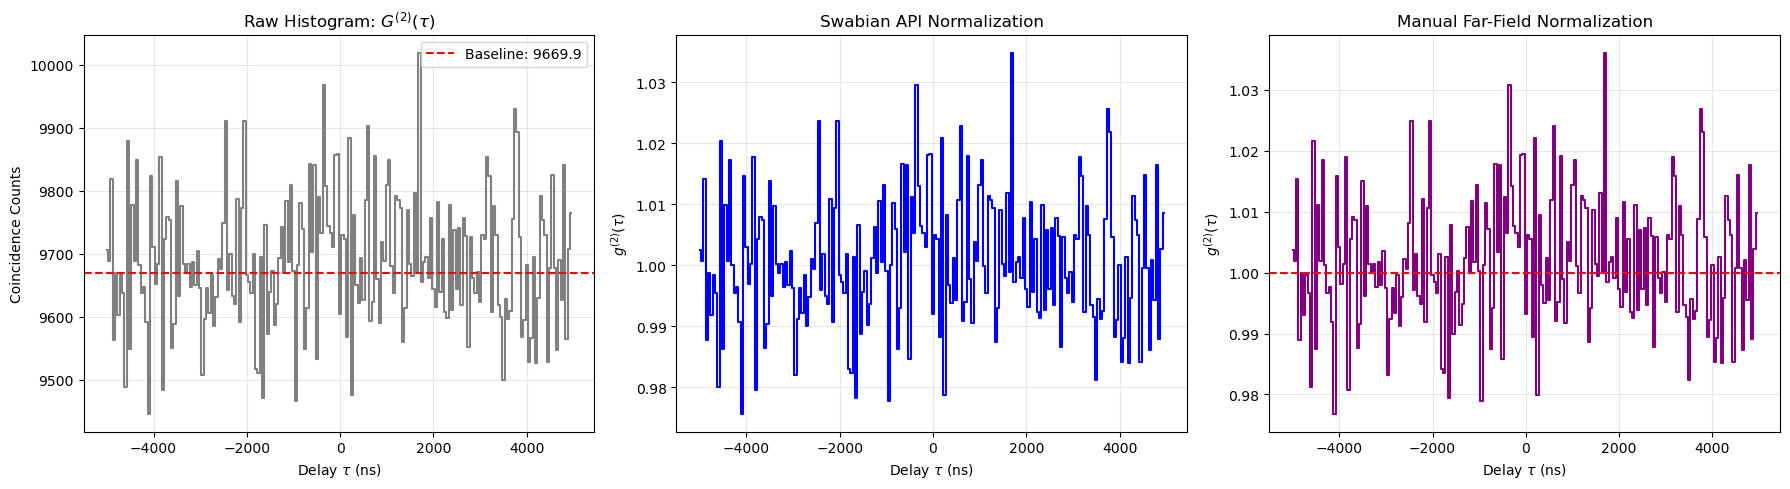

Pipeline complete. Hardware released.


In [ ]:
# --- EXPERIMENTAL SETUP ---
PAIRS_TO_MEASURE = [(1, 3), (1,4),(1,5),(1,6),(1,7),(1,8),(1,9),(1,10),(1,12),(1,13),(1,14),(1,15)]  # tuples to test
G2_BIN_WIDTH_PS = 50000               # 50 ns resolution
G2_N_BINS = 200                       # Captures +/- 10 microseconds
G2_EXPOSURE_TIME_PS = int(20e12)      # 20 seconds per pair

for (ch_ref, ch_sig) in PAIRS_TO_MEASURE:
    print(f"\n--- Measuring g2(tau) for Pair: Ch {ch_ref} vs Ch {ch_sig} ---")
    corr = tt.Correlation(tagger, ch_ref, ch_sig, binwidth=G2_BIN_WIDTH_PS, n_bins=G2_N_BINS)
    
    corr.startFor(G2_EXPOSURE_TIME_PS, clear=True)
    corr.waitUntilFinished()
    
    lags = corr.getIndex()                 
    G2_raw = corr.getData()                
    g2_swabian = corr.getDataNormalized()  
    
    # Save data
    np.save(os.path.join(SAVE_DIR, f"g2_raw_ch{ch_ref}_ch{ch_sig}.npy"), G2_raw)
    np.save(os.path.join(SAVE_DIR, f"g2_lags.npy"), lags) # Only need to save lags once
    
    # Far field normalization
    far_field_limit = 0.8 * np.max(lags)
    baseline_mask = (np.abs(lags) > far_field_limit)
    baseline_avg = np.mean(G2_raw[baseline_mask])
    
    # Prevent division by zero if count rates were too low
    g2_manual = G2_raw / baseline_avg if baseline_avg > 0 else np.zeros_like(G2_raw)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(lags / 1000, G2_raw, drawstyle='steps-mid', color='gray')
    axes[0].axhline(baseline_avg, color='red', linestyle='--', label=f'Baseline: {baseline_avg:.1f}')
    axes[0].set_title(r"Raw Histogram: $G^{(2)}(\tau)$")
    axes[0].set_xlabel("Delay $\\tau $ (ns)")
    axes[0].set_ylabel("Coincidence Counts")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].plot(lags / 1000, g2_swabian, drawstyle='steps-mid', color='blue')
    axes[1].set_title("Swabian API Normalization")
    axes[1].set_xlabel("Delay $\\tau $ (ns)")
    axes[1].set_ylabel(r"$g^{(2)}(\tau)$")
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(lags / 1000, g2_manual, drawstyle='steps-mid', color='purple')
    axes[2].axhline(1.0, color='red', linestyle='--')
    axes[2].set_title("Manual Far-Field Normalization")
    axes[2].set_xlabel("Delay $\\tau $ (ns)")
    axes[2].set_ylabel(r"$g^{(2)}(\tau)$")
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Free the hardware
tt.freeTimeTagger(tagger)

# DATA ANALYSIS

## Correlation ($g^{(2)}(\tau)$)
Visualize the data

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Data path 
data_folder = "../data/raw/correlation_15ch/data_cw_correlations_run2"
ch_ref = 1   # Change to your start pixel
ch_sig = 2   # Change to your stop pixel

# File path
lags_path = os.path.join(data_folder, "g2_lags.npy")
counts_path = os.path.join(data_folder, f"g2_raw_ch{ch_ref}_ch{ch_sig}.npy")

if not os.path.exists(lags_path) or not os.path.exists(counts_path):
    print("Error: Could not find the data files. Check your folder path and channel numbers.")
else:
    lags = np.load(lags_path)
    G2_raw = np.load(counts_path)

    # Far field normalization
    far_field_limit = 0.8 * np.max(np.abs(lags))
    baseline_mask = (np.abs(lags) > far_field_limit)
    baseline_avg = np.mean(G2_raw[baseline_mask])
    
    print(f"Calculated coincidence baseline: {baseline_avg:.2f} counts")

    # Normalize the raw counts by the baseline (avoiding division by zero)
    if baseline_avg > 0:
        g2_norm = G2_raw / baseline_avg
    else:
        g2_norm = np.zeros_like(G2_raw)
        print("Warning: Baseline is zero. Check your raw count rates.")

    # Plot
    plt.figure(figsize=(9, 5))
    
    # Convert lags from picoseconds to nanoseconds for a cleaner X-axis
    plt.plot(lags / 1000, g2_norm, drawstyle='steps-mid', color='purple', alpha=0.9, label='Measured Data')
    
    # Add the theoretical coherent light baseline
    plt.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Theoretical Coherent Baseline ($g^{(2)}(\\tau) = 1$)',alpha=0.5)
    
    plt.title(f"Normalized Second-Order Coherence: CW Laser (Ch {ch_ref} vs Ch {ch_sig})", fontsize=14)
    plt.xlabel(r"Delay $\tau$ (ns)", fontsize=12)
    plt.ylabel(r"$g^{(2)}(\tau)$", fontsize=12)
    
    # Zoom the Y-axis tightly around 1.0 to prove how flat the curve is
    plt.ylim(0.8, 1.2) 
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    plt.show()

Error: Could not find the data files. Check your folder path and channel numbers.


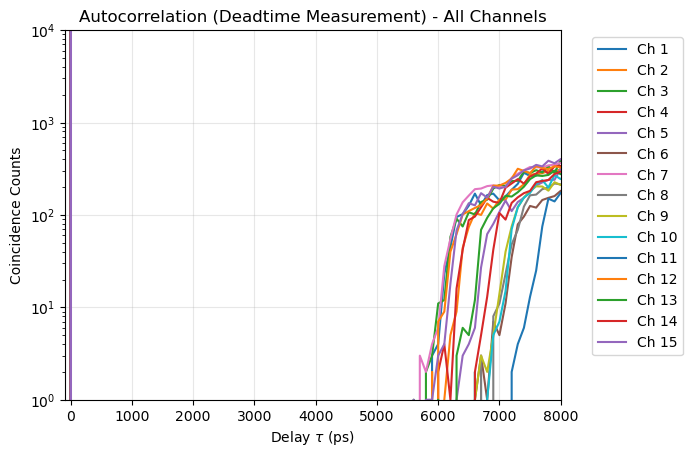

In [17]:
plt.figure()
for ch in list(range(1,16)):
    lags = np.load(f"{data_folder}/autocorr_lags.npy")
    autocorr = np.load(f"{data_folder}/autocorr_raw_ch{ch}.npy")
    plt.plot(lags,autocorr,label=f'Ch {ch}')
plt.yscale("log")
plt.xlim(-100,8000)
plt.ylim(1,10000)
plt.title("Autocorrelation (Deadtime Measurement) - All Channels")
plt.xlabel("Delay $\\tau$ (ps)")
plt.ylabel("Coincidence Counts")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
